In [8]:
#An analysis of relevant stock price responses to highly publicized events.
#Focused on the Stargate data center in Abilene, Texas, developed by Crusoe.

#Requires installation of the following, if necessary:
#pip install os yfinance numpy pandas matplotlib seaborn scipy statsmodels

In [9]:
#necessary imports
import os
import zipfile, io
import requests
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as st
from statsmodels.regression.linear_model import OLS
from datetime import datetime, timedelta

#select tickers
equipmentTickers = [
    'ETN',
    'GEV',
    'PH'
]

powerTickers = [
    'VST',
    'CEG'
]

smrTickers = [
    'SMR',
    'OKLO',
    'NNE'
]

controlTickers = [
    'SPY'
]

allTickers = equipmentTickers + powerTickers + smrTickers + controlTickers

#events
events = [
    ("2024-06-05", "Crusoe begins construction"),
    ("2024-10-01", "Phase One build-to-suit construction announced"),
    ("2025-01-21", "White House announces Stargate at press conference"),
    ("2025-03-07", "OpenAI and Oracle announce planned GPU deployment"),
    ("2025-03-10", "Phase Two construction (six buildings) underway"),
    ("2025-05-22", "JPMorgan and Crusoe give substantial funds"),
    ("2025-09-23", "First building goes live"),
    ("2026-03-07", "Expansion canceled; winter outage revealed"),
]

eventsdf = pd.DataFrame(events, columns = ['date', 'eventDescription'])
eventsdf['date'] = pd.to_datetime(eventsdf['date'])
dates = eventsdf['date']

#download daily ticker prices (at close)
#begin one year before the first estimation window 
#first estimation window begins two days before first event on the list
downloadWindowStart = dates.min() - timedelta(days = 367)
downloadWindowEnd = datetime.today().strftime('%Y-%m-%d')

allPrices = yf.download(
    tickers = allTickers,
    start = downloadWindowStart,
    end = downloadWindowEnd,
    auto_adjust = True,
    progress = False
)["Close"]
allPrices.fillna(0, inplace = True)

allReturns = ((allPrices.shift(-1) / allPrices).shift(1)).tail(-1)
allLogReturns = np.log(allReturns)
allReturns.fillna(0, inplace = True)
allLogReturns.fillna(0, inplace = True)
allReturns.replace([np.inf, -np.inf], 0, inplace = True)
allLogReturns.replace([np.inf, -np.inf], 0, inplace = True)

allPricesDestination = "data/allPrices.csv"
allReturnsDestination = "data/allReturns.csv"
allLogReturnsDestination = "data/allLogReturns.csv"

allPrices.to_csv(allPricesDestination)
allReturns.to_csv(allReturnsDestination)
allLogReturns.to_csv(allLogReturnsDestination)

In [10]:
#compute returns for equal-weighted portfolios of each treatment category

ecolumns = []
le = len(equipmentTickers)
for etick in equipmentTickers:
    ecolumns.append(etick)
eReturns = pd.DataFrame(columns = ecolumns)
for ecol in ecolumns:
    eReturns[ecol] = allReturns[ecol]

eReturns.insert(
    loc = len(ecolumns),
    column = 'weightedReturn',
    value = 0.0
)
for etick in equipmentTickers:
    eReturns.insert(
        loc = len(ecolumns),
        column = f'{etick} weight',
        value = 0.0
    )
    
for tradingDay in eReturns.itertuples():
    enz = []
    for etick in equipmentTickers:
        zero = getattr(tradingDay, etick) == 0
        nonzero = getattr(tradingDay, etick) != 0
        if zero: eReturns.loc[tradingDay.Index, f'{etick} weight'] = 0
        if nonzero: enz.append(etick)

    for etick in enz:
        eweight = 1 / (len(enz))
        eReturns.loc[tradingDay.Index, f'{etick} weight'] = eweight
        eReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            eReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (eweight * eReturns.loc[tradingDay.Index, etick])
        )

eReturns.replace([np.inf, -np.inf], 0, inplace = True)
eReturnsDestination = "data/eReturns.csv"
eReturns.to_csv(eReturnsDestination)

                  
pcolumns = []
lp = len(powerTickers)
for ptick in powerTickers:
    pcolumns.append(ptick)
pReturns = pd.DataFrame(columns = pcolumns)
for pcol in pcolumns:
    pReturns[pcol] = allReturns[pcol]

pReturns.insert(
    loc = len(pcolumns),
    column = 'weightedReturn',
    value = 0.0
)
for ptick in powerTickers:
    pReturns.insert(
        loc = len(pcolumns),
        column = f'{ptick} weight',
        value = 0.0
    )
    
for tradingDay in pReturns.itertuples():
    pnz = []
    for ptick in powerTickers:
        zero = getattr(tradingDay, ptick) == 0
        nonzero = getattr(tradingDay, ptick) != 0
        if zero: pReturns.loc[tradingDay.Index, f'{ptick} weight'] = 0
        if nonzero: pnz.append(ptick)

    for ptick in pnz:
        pweight = 1 / (len(pnz))
        pReturns.loc[tradingDay.Index, f'{ptick} weight'] = pweight
        pReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            pReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (pweight * pReturns.loc[tradingDay.Index, ptick])
        )

pReturns.replace([np.inf, -np.inf], 0, inplace = True)
pReturnsDestination = "data/pReturns.csv"
pReturns.to_csv(pReturnsDestination)


scolumns = []
ls = len(smrTickers)
for stick in smrTickers:
    scolumns.append(stick)
sReturns = pd.DataFrame(columns = scolumns)
for scol in scolumns:
    sReturns[scol] = allReturns[scol]

sReturns.insert(
    loc = len(scolumns),
    column = 'weightedReturn',
    value = 0.0
)
for stick in smrTickers:
    sReturns.insert(
        loc = len(scolumns),
        column = f'{stick} weight',
        value = 0.0
    )
    
for tradingDay in sReturns.itertuples():
    snz = []
    for stick in smrTickers:
        zero = getattr(tradingDay, stick) == 0
        nonzero = getattr(tradingDay, stick) != 0
        if zero: sReturns.loc[tradingDay.Index, f'{stick} weight'] = 0
        if nonzero: snz.append(stick)

    for stick in snz:
        sweight = 1 / (len(snz))
        sReturns.loc[tradingDay.Index, f'{stick} weight'] = sweight
        sReturns.loc[tradingDay.Index, 'weightedReturn'] = (
            sReturns.loc[tradingDay.Index, 'weightedReturn'] +
            (sweight * sReturns.loc[tradingDay.Index, stick])
        )

sReturns.replace([np.inf, -np.inf], 0, inplace = True)
sReturnsDestination = "data/sReturns.csv"
sReturns.to_csv(sReturnsDestination)

In [11]:
#incorporate Fama-French three-factor model daily returns
#originally tried with pandas_datareader
#encountered compatibility issue that way
#used requests and zipfile instead

#Fama-French five factor returns have been added as well

url3 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
url5 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"

def getff(url, ffstart, ffend):
    response = requests.get(url)
    zf = zipfile.ZipFile(io.BytesIO(response.content)) 
    name = zf.namelist()[0]

    with zf.open(name) as f:
        
        #drop header rows
        #manually add encoding parameter just to be safe
        allff = pd.read_csv(f, skiprows = 4, index_col = 0, encoding = 'utf-8')
        
        #drop any remaining non-numeric rows (footer, etc)
        allff = allff[pd.to_numeric(allff['Mkt-RF'], errors = 'coerce').notna()]

        #change index column (the date) to datetime format
        allff.index = pd.to_datetime(allff.index, format = '%Y%m%d')

        #narrow it down to desired dates
        allff = allff.loc[ffstart:ffend]

        #change all factor returns (the whole dataframe) to float
        allff = allff.astype(float)

        #turn them into percentages in same format as our other returns
        allff = allff / 100
        allff = allff + 1

    return allff
    
ff3 = getff(url3, (downloadWindowStart + timedelta(days = 2)), 
            downloadWindowEnd)
ff5 = getff(url5, (downloadWindowStart + timedelta(days = 2)), 
            downloadWindowEnd)


#add index names for cleanliness
ff3.index.name = 'Date'
ff5.index.name = 'Date'
#add the daily portfolio returns 
portfolioReturns = {
    'e': eReturns,
    'p': pReturns,
    's': sReturns
}

for pname, portfolio in portfolioReturns.items():
    ff3 = pd.merge(ff3, portfolio['weightedReturn'],
                   left_index = True, right_index = True, how = 'inner')
    i = len(ff3.columns)
    ff3.columns.values[i-1] = f'{pname}Weighted'

    ff5 = pd.merge(ff5, portfolio['weightedReturn'],
                    left_index = True, right_index = True, how = 'inner')
    i = len(ff5.columns)
    ff5.columns.values[i-1] = f'{pname}Weighted'

In [53]:
#using the columns of the ff3 dataframe, find factor betas
ff3['eExcess'] = ff3['eWeighted'] - ff3['RF']
ff3['pExcess'] = ff3['pWeighted'] - ff3['RF']
ff3['sExcess'] = ff3['sWeighted'] - ff3['RF']

#print(ff3.tail())

x3 = ff3[['Mkt-RF', 'SMB', 'HML']]
x3 = st.add_constant(x3)

e3Model = OLS(
    ff3['eExcess'],
    exog = x3, 
    missing = 'none',
    hasconst = True
)

p3Model = OLS(
    ff3['pExcess'],
    exog = x3, 
    missing = 'none',
    hasconst = True
)

s3Model = OLS(
    ff3['sExcess'],
    exog = x3, 
    missing = 'none',
    hasconst = True
)

e3Results = e3Model.fit()
#print("e3results:")
#print(e3Results.summary())

p3Results = p3Model.fit()
#print("p3results:")
#print(p3Results.summary())

s3Results = s3Model.fit()
#print("s3results:")
#print(s3Results.summary())

#repeat the entire process with ff5 dataframe (Fama-French five-factor)
ff5['eExcess'] = ff5['eWeighted'] - ff5['RF']
ff5['pExcess'] = ff5['pWeighted'] - ff5['RF']
ff5['sExcess'] = ff5['sWeighted'] - ff5['RF']

#print(ff5.tail())

x5 = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
x5 = st.add_constant(x5)

e5Model = OLS(
    ff5['eExcess'],
    exog = x5, 
    missing = 'none',
    hasconst = True
)

p5Model = OLS(
    ff5['pExcess'],
    exog = x5, 
    missing = 'none',
    hasconst = True
)

s5Model = OLS(
    ff5['sExcess'],
    exog = x5, 
    missing = 'none',
    hasconst = True
)


e5Results = e5Model.fit()
#print("e5Results:")
#print(e5Results.summary())

p5Results = p5Model.fit()
#print("p5results:")
#print(p5Results.summary())

s5Results = s5Model.fit()
#print("s5results:")
#print(s5Results.summary())

1.4189078237660222 1.5308442983057235 1.3069713492263209
1.4276462431406762 1.54101241484381 1.3142800714375424
0.13252635862576212 0.283791583718817 -0.01873886646729278
0.07261266341784917 0.24406439620846934 -0.09883906937277101
-0.04267165578884184 0.10064388047578958 -0.18598719205347325
-0.08896783050964062 0.08200391152995411 -0.25993957254923533
0.25599187484112074 0.47387929540751295 0.0381044542747285
-0.060150590171155704 0.15163459249562974 -0.2719357728379411
1.4928876135987545 1.7258572523762625 1.2599179748212466
1.494685039720525 1.7298760174074594 1.2594940620335904
-0.020432590573330085 0.2943906606898545 -0.33525584183651463
-0.18239276932258142 0.1733032911101472 -0.53808882975531
-0.7411569251596353 -0.4428790952380398 -1.0394347550812308
-0.7584227565926155 -0.403722491398611 -1.11312302178662
0.6709581858834743 1.122990345908134 0.21892602585881454
-0.2045653459227615 0.23480702965186806 -0.643937721497391
1.8343102631944301 2.3067386076782057 1.3618819187106546


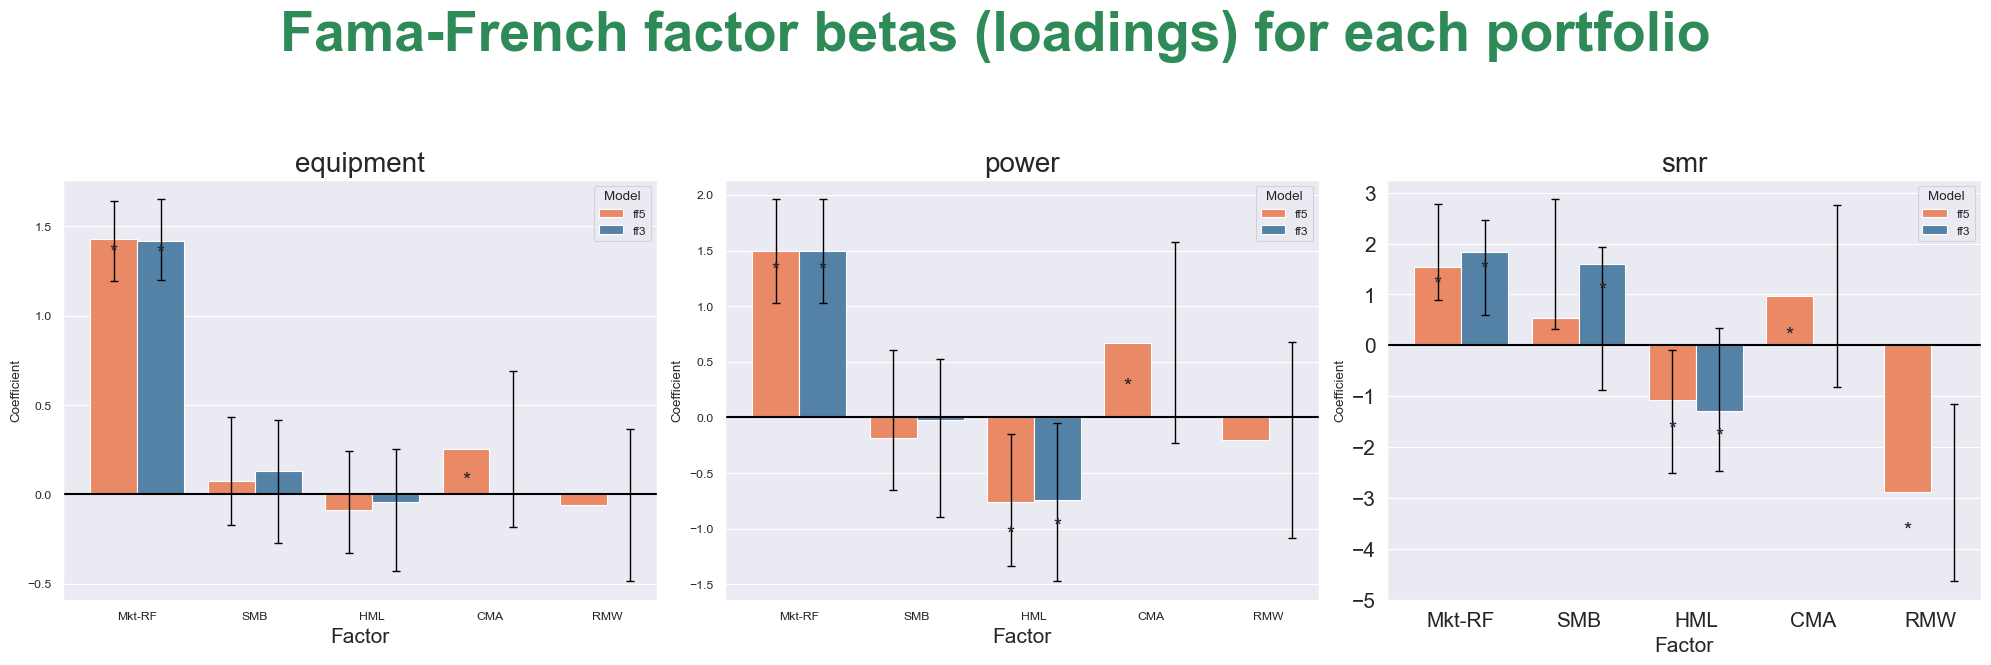

In [78]:
#extract the coefficients from OLS and create visuals
fig, axes = plt.subplots(1, 3, figsize = (20,6), sharey = False)

ff3factors = ['Mkt-RF', 'SMB', 'HML']
ff5factors = ['Mkt-RF', 'SMB', 'HML', 'CMA', 'RMW']
models = {
    'equipment': (e3Results, e5Results),
    'power': (p3Results, p5Results),
    'smr': (s3Results, s5Results)
}

for axis, (modelName, (model3, model5)) in zip(axes, models.items()):
    bars = []

    for factor in ff5factors:
        if factor in ff3factors:
            bars.append({
                'factor': factor,
                'model': 'ff3',
                'coefficient': model3.params[factor],
                'ci_lower': model3.conf_int().loc[factor, 0],
                'ci_upper': model3.conf_int().loc[factor, 1],
                'pvalue': model3.pvalues[factor]
            })
        bars.append({
            'factor': factor,
            'model': 'ff5',
            'coefficient': model5.params[factor],
            'ci_lower': model5.conf_int().loc[factor, 0],
            'ci_upper': model5.conf_int().loc[factor, 1],
            'pvalue': model5.pvalues[factor]
        })

    plotBars = pd.DataFrame(bars)

    sb.barplot(
        data = plotBars,
        x = 'factor',
        y = 'coefficient',
        hue = 'model',
        order = ff5factors,
        hue_order = ['ff5', 'ff3'],
        palette = {
            'ff3': 'steelblue', 'ff5': 'coral'
        },
        ax = axis,
    )

    axis.axhline(y=0, color='black', linewidth=1.5)
    axis.set_title(modelName, fontsize=20)
    axis.set_xlabel('Factor', fontsize=15)
    axis.set_ylabel('Coefficient')
    axis.legend(title='Model')
    plt.tick_params(axis = 'x', labelsize = 15)
    plt.tick_params(axis = 'y', labelsize = 15)

    barPositions = {factor: i for i, factor in enumerate(ff5factors)}
    offsets = {'ff3': -0.2, 'ff5': 0.2}

    for tuple in plotBars.itertuples():
        x = barPositions[tuple.factor] + offsets[tuple.model]
        print(tuple.coefficient, tuple.ci_upper, tuple.ci_lower)

        axis.errorbar(
            x = barPositions[tuple.factor] + offsets[tuple.model],
            y = tuple.coefficient,
            yerr = tuple.ci_upper - tuple.ci_lower,
            fmt = 'None',
            capsize = 3,
            linewidth = 1,
            barsabove = True,
            ecolor = 'black'
        )

        if tuple.pvalue < 0.05:
            axis.text(
                x = barPositions[tuple.factor] - offsets[tuple.model],
                y = tuple.ci_lower + 0.01,
                s = '*',
                ha='center',
                fontsize=15
            )
        



plt.suptitle(
    'Fama-French factor betas (loadings) for each portfolio',
    fontsize = 40,
    color = 'seagreen',
    fontweight = 'bold',
    y = 1.1
)

plt.tight_layout()
sb.set_theme('paper')
plt.show()
